# 01 - NVDA EDA

Goal: understand price, return, risk, and feature relationships before modeling.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from nvda_rl.data_downloader import load_prices
from nvda_rl.features import add_market_features

sns.set_theme(style="whitegrid", context="notebook")

## Load saved data

This notebook does not download data. Run `scripts/download_data.py` first when the CSV needs refreshing.

In [3]:
raw_path = PROJECT_ROOT / "data" / "raw" / "nvda_daily.csv"
prices = load_prices(raw_path)
print(f"Rows: {len(prices):,}")
print(f"Range: {prices['date'].min().date()} to {prices['date'].max().date()}")
prices.head()

Rows: 4,107
Range: 2010-01-04 to 2026-05-01


,date,adj_close,close,high,low,open,volume
0,2010-01-04,0.423784,0.46225,0.4655,0.45275,0.46275,800204000
1,2010-01-05,0.429972,0.46900,0.4740,0.46050,0.46050,728648000
2,2010-01-06,0.432722,0.47200,0.4730,0.46425,0.46875,649168000
3,2010-01-07,0.424242,0.46275,0.4715,0.45925,0.46950,547792000
4,2010-01-08,0.425159,0.46375,0.4670,0.45625,0.45900,478168000


## Build features

`add_market_features()` creates returns, volatility, momentum, volume z-score, drawdown, RSI, MACD, moving-average gaps, and ATR.

In [4]:
data = add_market_features(prices)
data.to_csv(PROJECT_ROOT / "data" / "processed" / "nvda_features.csv", index=False)

feature_preview = [
    "date", "adj_close", "return", "volatility_20d", "momentum_20d",
    "rsi_14", "macd_hist", "sma_50_gap", "atr_14_pct", "drawdown"
]
data[feature_preview].head()

,date,adj_close,return,volatility_20d,momentum_20d,rsi_14,macd_hist,sma_50_gap,atr_14_pct,drawdown
0,2010-03-16,0.407052,0.034965,0.024878,0.005093,65.796404,0.002430,0.041178,0.032770,-0.059322
1,2010-03-17,0.414845,0.019144,0.025151,0.014574,71.144280,0.003103,0.061596,0.031251,-0.041314
2,2010-03-18,0.400177,-0.035359,0.021594,0.047391,64.125609,0.002413,0.025623,0.034583,-0.075212
3,2010-03-19,0.395363,-0.012028,0.021773,0.040410,54.975179,0.001527,0.015231,0.034507,-0.086335
4,2010-03-22,0.401781,0.016232,0.021996,0.055388,58.041936,0.001279,0.032902,0.034312,-0.071504


RSI shows stretched up/down moves, MACD shows trend change, and ATR shows daily range risk.

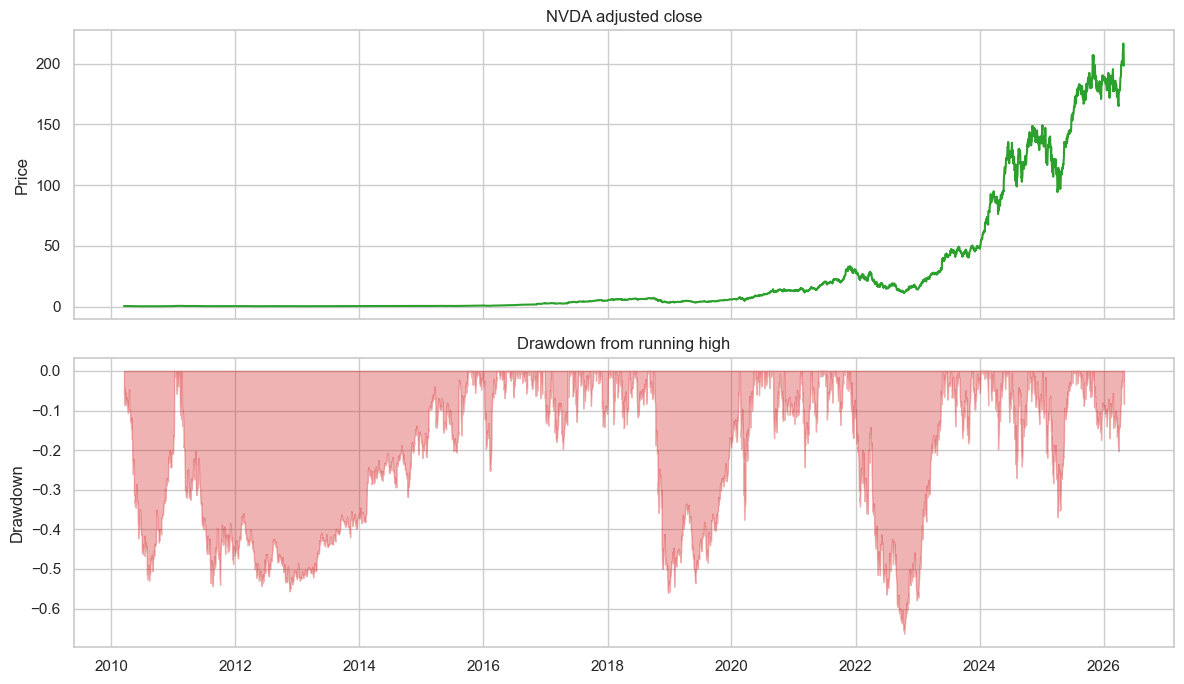

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(data["date"], data["adj_close"], color="tab:green")
axes[0].set_title("NVDA adjusted close")
axes[0].set_ylabel("Price")

axes[1].fill_between(data["date"], data["drawdown"], 0, color="tab:red", alpha=0.35)
axes[1].set_title("Drawdown from running high")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.show()

After feature warmup, NVDA grew from about $0.41 to $198.45. That huge gain still came with a max drawdown near -66%, so risk control matters.

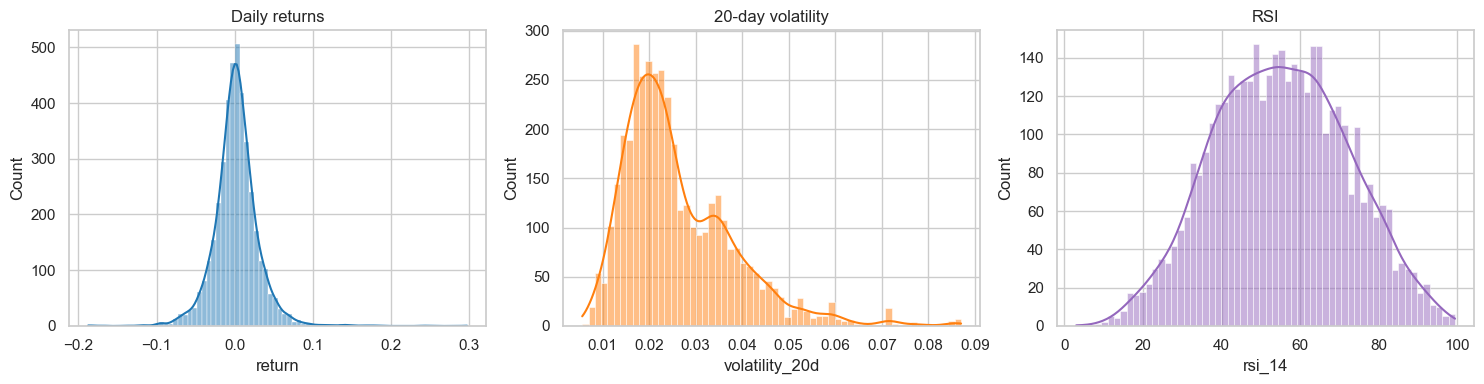

,count,mean,std,min,25%,50%,75%,max
return,4058.0,0.001943,0.028703,-0.187559,-0.012313,0.001777,0.016263,0.298067
volatility_20d,4058.0,0.026152,0.011942,0.005627,0.017732,0.023043,0.033070,0.087022
momentum_20d,4058.0,0.039038,0.128857,-0.374189,-0.037999,0.029504,0.110197,0.657507
rsi_14,4058.0,55.078710,17.004850,2.978655,42.551248,54.847940,67.346434,99.429031
atr_14_pct,4058.0,0.036860,0.014423,0.014801,0.026394,0.032957,0.044422,0.121571
drawdown,4058.0,-0.210093,0.182459,-0.663351,-0.387071,-0.151131,-0.046189,0.000000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data["return"], bins=80, kde=True, ax=axes[0], color="tab:blue")
axes[0].set_title("Daily returns")
sns.histplot(data["volatility_20d"], bins=60, kde=True, ax=axes[1], color="tab:orange")
axes[1].set_title("20-day volatility")
sns.histplot(data["rsi_14"], bins=60, kde=True, ax=axes[2], color="tab:purple")
axes[2].set_title("RSI")
plt.tight_layout()
plt.show()

data[["return", "volatility_20d", "momentum_20d", "rsi_14", "atr_14_pct", "drawdown"]].describe().T

Average daily return is about 0.19%, while daily volatility is about 2.87%. Single-day moves ranged from about -18.8% to +29.8%, so the tails are meaningful.

## Correlations

Correlations show which features move together and which may add new information.

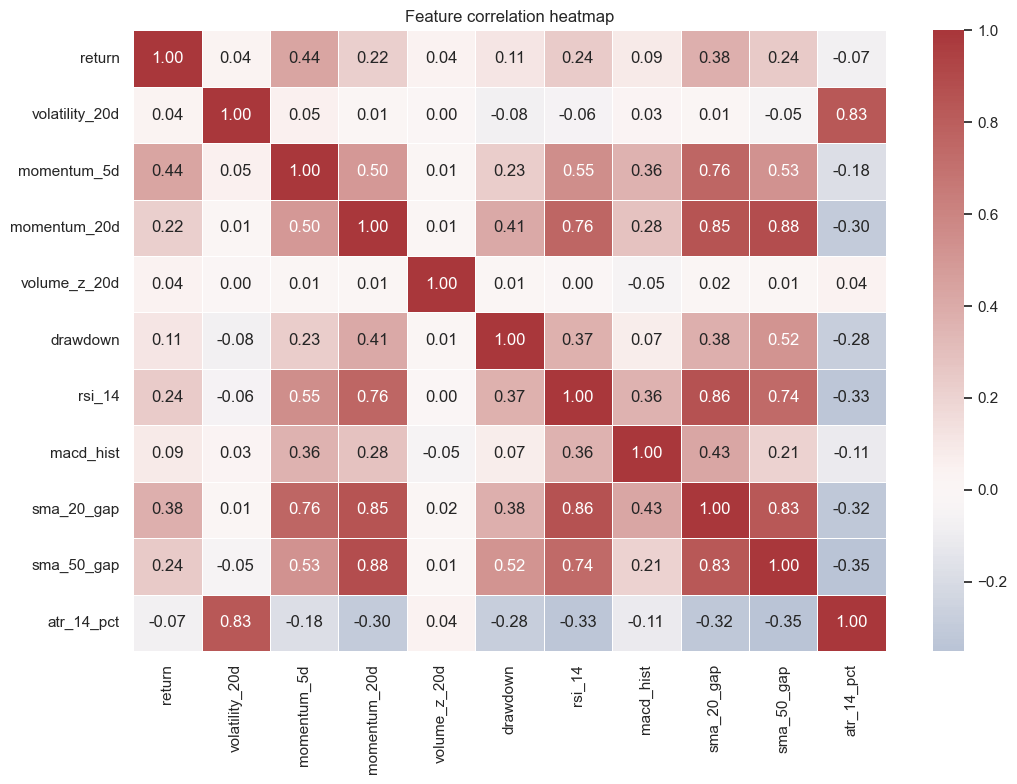

return            1.000000
momentum_5d       0.435137
sma_20_gap        0.379457
sma_50_gap        0.244333
rsi_14            0.238472
momentum_20d      0.221901
drawdown          0.110966
macd_hist         0.088570
volume_z_20d      0.042929
volatility_20d    0.036339
atr_14_pct       -0.074481
Name: return, dtype: float64

In [7]:
corr_cols = [
    "return", "volatility_20d", "momentum_5d", "momentum_20d",
    "volume_z_20d", "drawdown", "rsi_14", "macd_hist",
    "sma_20_gap", "sma_50_gap", "atr_14_pct"
]
corr = data[corr_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

corr["return"].sort_values(ascending=False)

The strongest return relationship is with 5-day momentum at about 0.44 correlation. ATR is slightly negative, which suggests high range-risk days are not automatically good return days.

C:\Users\Nitro\AppData\Local\Temp\ipykernel_43968\3518338375.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data.set_index("date")["return"].resample("M").agg(["mean", "std"])


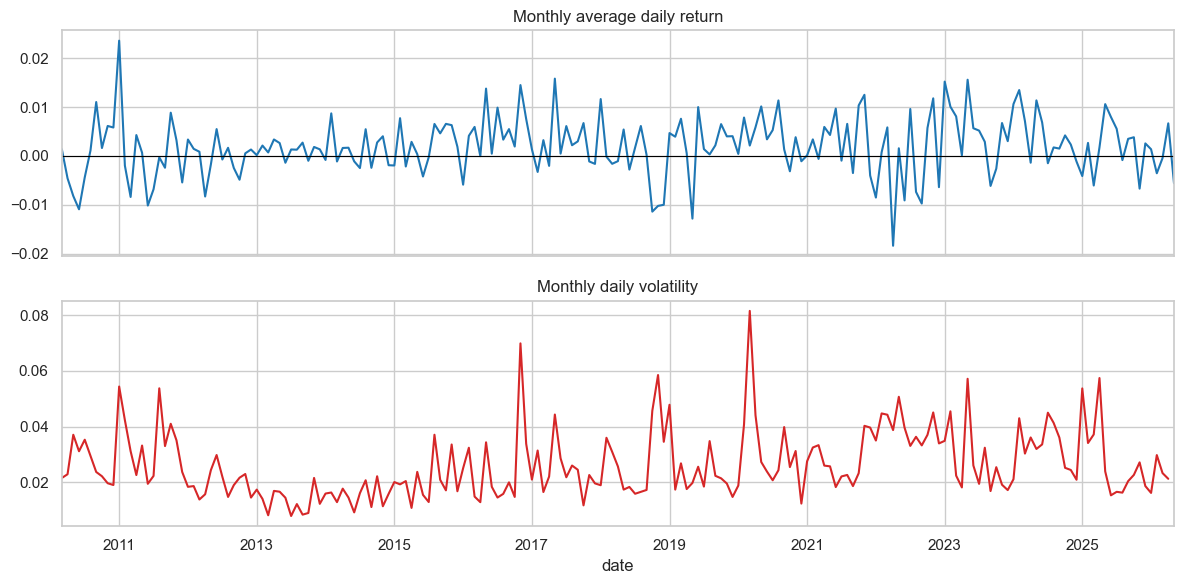

In [8]:
monthly = data.set_index("date")["return"].resample("M").agg(["mean", "std"])
monthly.columns = ["monthly_avg_daily_return", "monthly_daily_volatility"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
monthly["monthly_avg_daily_return"].plot(ax=axes[0], color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Monthly average daily return")
monthly["monthly_daily_volatility"].plot(ax=axes[1], color="tab:red")
axes[1].set_title("Monthly daily volatility")
plt.tight_layout()
plt.show()

Volatility clearly clusters in certain periods. A trading rule trained on calm periods may behave poorly in stress periods.